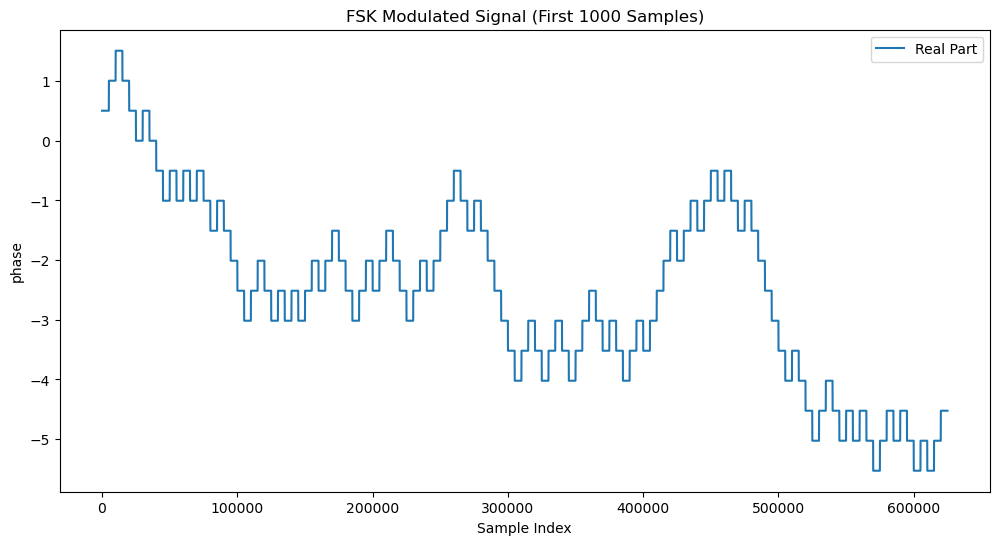

[INFO] [B200] Detected Device: B210
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 32.000000 MHz... 
[INFO] [B200] Actually got clock rate 32.000000 MHz.


[TX] FSK signal transmitted.


In [10]:
#!/usr/bin/env python3
"""
Transmit FSK with:
- FSK Modulation (Frequency-based)
- Preamble for Frame Sync

via UHD on a USRP B210.

NOTE: This is a conceptual demonstration; it's not rigorously tested or tuned.
"""

import uhd
import time
import numpy as np
import matplotlib.pyplot as plt

#########################
# Configurable Settings #
#########################
TX_RATE   = 2e6   # Symbol rate (symbols per second)
FREQ      = 2.5e9  # Transmission frequency
GAIN      = 89.8    # TX gain in dB
SPS       = 5000      # Samples per symbol (oversampling factor)
PREAMBLE  = [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]  # Preamble pattern (Barker-ish)
PAYLOAD   = "Hello from FSK"  # Payload message to transmit
#######################################################

def bits_to_symbols(bit_list):
    """
    Convert list/array of bits to frequency shift symbols.
    Maps '1' to +1 and '0' to -1.
    
    Parameters:
    - bit_list: List or numpy array of bits (0 or 1)
    
    Returns:
    - symbols: Numpy array of symbols (+1 or -1)
    """
    bit_array = np.array(bit_list)

    # Validate that the bits are binary (0 or 1)
    if not np.all((bit_array == 0) | (bit_array == 1)):
        raise ValueError("All bits must be 0 or 1.")

    # Map bits to symbols: 1 -> +1.0, 0 -> -1.0
    symbols = np.where(bit_array == 1, 1.0, -1.0).astype(np.float32)

    return symbols

def string_to_bits(s):
    """
    Convert ASCII string to a list of bits (MSB first).
    
    Parameters:
    - s: Input string
    
    Returns:
    - bits: List of bits (0 or 1)
    """
    bits = []
    for char in s:
        bin_repr = format(ord(char), '08b')  # 8-bit binary
        bits.extend([int(b) for b in bin_repr])
    return bits

def upsample(symbols, sps):
    """
    Upsample the symbol stream by inserting zeros between symbols.
    
    Parameters:
    - symbols: Numpy array of symbols
    - sps: Samples per symbol
    
    Returns:
    - upsampled: Upsampled symbol array
    """
    upsampled = np.zeros(len(symbols) * sps, dtype=np.float32)
    upsampled[::sps] = symbols
    return upsampled

def fsk_modulate(bits, sps):
    """
    Perform FSK modulation on a bit stream.
    
    Parameters:
    - bits: List or numpy array of bits (0 or 1)
    - sps: Samples per symbol (oversampling factor)
    
    Returns:
    - fsk_signal: Complex baseband FSK signal
    """
    # Map bits to symbols (+1 for '1', -1 for '0')
    symbols = bits_to_symbols(bits)

    # Upsample symbols by inserting zeros
    upsampled = upsample(symbols, sps)

    # Frequency deviation (\u0394f). This determines the frequency shift for '1' and '0'.
    delta_f = 1 * TX_RATE / sps  # Example value; adjust as needed

    # Integrate the upsampled signal to get phase
    phase = 2 * np.pi * delta_f * np.cumsum(upsampled) / sps

    # Generate complex baseband signal
    fsk_signal = np.exp(1j * phase).astype(np.complex64)

    return fsk_signal
tx_samples =None
def main():
    global tx_samples
    #------------------------------------
    # 1. Prepare Data
    #------------------------------------
    # Convert payload string to bits
    payload_bits = string_to_bits(PAYLOAD)
    # Combine preamble and payload
    tx_bits = PREAMBLE + payload_bits

    # FSK Modulation
    fsk_signal = fsk_modulate(tx_bits, SPS)

    # Optional: Visualize the transmitted signal
    plt.figure(figsize=(12, 6))
    plt.plot(np.unwrap(np.angle(fsk_signal)), label="Real Part")

    plt.title("FSK Modulated Signal (First 1000 Samples)")
    plt.xlabel("Sample Index")
    plt.ylabel("phase")
    plt.legend()
    plt.show()

    #------------------------------------
    # 2. Setup USRP
    #------------------------------------
    # Initialize USRP device (specify serial number if needed)
    usrp = uhd.usrp.MultiUSRP("serial=8000169")  # Replace with your USRP's serial or remove parameter for default


    # Transmit signal
    for i in range(2):
        usrp.send_waveform(fsk_signal, len(fsk_signal)/TX_RATE  , FREQ, TX_RATE, [0], GAIN)
        time.sleep(0.1)

        

    print("[TX] FSK signal transmitted.")

if __name__ == "__main__":
    main()
